# **Tabular MLP and LSTM Fusion for Inference**

## 1. Introduction

In this notebook, the models developed in **`Project.ipynb`** (`LSTM`) and **`tabular_pipeline_aeolus_mlp.ipynb`** (`MLP`) are combined into a unified architecture.

>
>
>**Task:** Regression of flight-chain arrival and departure delay minutes.

The resulting model jointly predicts both **arrival** and **departure delays** by leveraging two complementary sources of information: **static tabular features** and **sequential flight-chain data**.

The `MLP` learns representations from aircraft, airport, operational, and weather-related features, while the `LSTM` captures temporal dependencies and delay propagation patterns within flight chains from the Aeolus dataset. By combining the representations extracted by these two models, the final architecture integrates static and sequential information to improve flight delay prediction.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shap
import pickle
import copy
import os
import time
import shutil
import kagglehub

import torch
import torch.nn as nn
from torch.utils.data import Subset
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

from IPython.display import display

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

SEED = 42

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Preprocessing

This notebook uses only data from **2022**. The original plan was to use data from **2022 to 2024**, as in the LightGBM and MLP experiments, but this was not feasible for the following reasons:

- **2024** was excluded because it does not contain the delay-minute labels required for the regression task.
- **2023** is suitable for the task, but the available RAM was insufficient to load the complete dataset (2022-2023) in the flight-chain format described below.

The original Aeolus flight-chain dataset contains only the sequential information required by the `LSTM` and does not preserve all the static tabular features associated with each flight. To overcome this limitation, the original 2022 `.csv` files were reprocessed (see `mlp_lstm_preprocessing.ipynb`) to recreate the Aeolus flight-chain structure while retaining the complete set of static features for each of the six flights in every chain. These features include both the original Aeolus variables and the engineered features introduced during preprocessing.

As a result, each sample consists of two synchronized representations of the same flight chain:

- the **sequential flight-chain representation**, used as input to the `LSTM`;
- the **additional reconstruction features**, introduced to enable the reconstruction of the complete tabular representation through the `tabular_rec()` function, which is then provided as input to the `MLP`.

> **Note:** The additional reconstruction features are necessary because the original sequential flight-chain representation does not contain sufficient information to recover all the static attributes of the flights in the chain. Using these features, the `tabular_rec()` function reconstructs the complete tabular representation for the exact same flights processed by the `LSTM`, ensuring that both branches receive synchronized inputs.

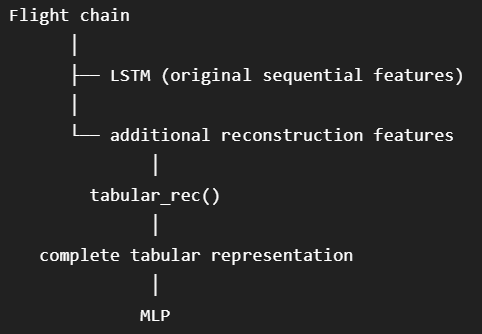





In [3]:
data_dir = "/content/drive/Othercomputers/local/Flight-Delay-Forecasting/data/chain/LSTM_MLP/"

train_dataset = torch.load(data_dir + "new_train_flight_chain_2022.pt",
                          weights_only=False)
val_dataset = torch.load(data_dir + "new_val_flight_chain_2022.pt",
                          weights_only=False)
test_dataset = torch.load(data_dir + "new_test_flight_chain_2022.pt",
                          weights_only=False)

datasets = {"train": train_dataset, "val": val_dataset, "test": test_dataset}

In [4]:
# example
# in this example Padding is used (1 flight out of 6 expected)

sample = datasets["train"][1]
print(f"Sample Type: {type(sample)}")
print(f"Total components in the sample tuple: {len(sample)}\n")
print("-" * 60)

dense_feat, sparse_feat, labels, valid_lens, delays, dense_additional = sample

print("1. Dense Features (Continuous / Meteorological Features):")
print(f"   - Shape: {dense_feat.shape} (Sequence Length x 6)")
print(f"   - Cols: ['O_TEMP', 'D_TEMP', 'O_PRCP', 'D_PRCP', 'O_WSPD', 'D_WSPD']")
print(f"    - Values:\n{dense_feat}\n")

print("2. Sparse Features (Categorical / Temporal Features):")
print(f"   - Shape: {sparse_feat.shape} (Sequence Length x 8)")
print(f"   - Cols: ['MONTH', 'DAY_OF_WEEK', 'CRS_ARR_TIME_HOUR', 'CRS_DEP_TIME_HOUR', 'ORIGIN_INDEX', 'DEST_INDEX', 'OP_CARRIER', 'OP_CARRIER_FL_NUM']")
print(f"    - Values:\n{sparse_feat}\n")

print("3. Binary Labels (Flight Delay Indicators > 15 mins):")
print(f"   - Shape: {labels.shape} (Sequence Length x 2)")
print(f"   - [(ARR_DELAY > 15), (DEP_DELAY > 15)]")
print(f"   - Values:\n{labels}\n")

print("4. Valid Sequence Lengths (Metadata):")
print(f"   - Description: Effective number of valid flights in the chain before padding")
print(f"   - Shape: {valid_lens.shape}")
print(f"   - Values: {valid_lens}\n")

print("5. Raw Delays (Ground Truth):")
print(f"   - Shape: {delays.shape} (Sequence Length x 2)")
print(f"   - Cols: ['ARR_DELAY', 'DEP_DELAY']")
print(f"   - Values:\n{delays}\n")

# Additional features introduced to enable the reconstruction of the tabular representation for each flight in the chain.

print("6. Dense Features Additional:")
print(f"   - Shape: {dense_additional.shape} (Sequence Length x 18)")
print(f"   - Cols: ['FL_YEAR', 'FL_DAY', 'FL_WEEK', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'O_LATITUDE', 'O_LONGITUDE', 'D_LATITUDE', 'D_LONGITUDE', 'dep_hour_sin', 'dep_hour_cos', 'arr_hour_sin', 'arr_hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'great_circle_km', 'origin_congestion_2h']")
print(f"    - Values:\n{dense_additional}")
print("-" * 60)

Sample Type: <class 'tuple'>
Total components in the sample tuple: 6

------------------------------------------------------------
1. Dense Features (Continuous / Meteorological Features):
   - Shape: torch.Size([6, 6]) (Sequence Length x 6)
   - Cols: ['O_TEMP', 'D_TEMP', 'O_PRCP', 'D_PRCP', 'O_WSPD', 'D_WSPD']
    - Values:
tensor([[22.8000, 10.6000,  0.0000,  0.0000, 22.3000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])

2. Sparse Features (Categorical / Temporal Features):
   - Shape: torch.Size([6, 8]) (Sequence Length x 8)
   - Cols: ['MONTH', 'DAY_OF_WEEK', 'CRS_ARR_TIME_HOUR', 'CRS_DEP_TIME_HOUR', 'ORIGIN_INDEX', 'DEST_INDEX', 'OP_CARRIER', 'OP_CARRIER_FL_NUM']
    - Values:
tensor([[   0,    5,  

In [5]:
# Feature Rescaling (valid := real flights (no padding))

def scale_tensors(targets, mean, std):
    return (targets - mean.to(targets.device)) / std.to(targets.device)

def unscale_tensors(scaled, mean, std):
    return scaled * std.to(scaled.device) + mean.to(scaled.device)

# 1. On delays

all_delays = train_dataset.tensors[4]      # [N, seq_len, 2]
all_valid_lens = train_dataset.tensors[3]  # [N]

seq_len = all_delays.shape[1]
mask = torch.arange(seq_len).unsqueeze(0) < all_valid_lens.unsqueeze(1)  # [N, seq_len]

valid_delays = all_delays[mask].float()  # [total_valid_steps, 2]

delay_mean = valid_delays.mean(dim=0)  # shape [2]
delay_std = valid_delays.std(dim=0)    # shape [2]

print(f"Delay mean (ARR, DEP): {delay_mean} \n")
print(f"Delay std (ARR, DEP): {delay_std} \n")

delay_threshold_scaled = scale_tensors(torch.tensor([15.0, 15.0]), mean=delay_mean, std=delay_std)
print(f"Delay threshold: {delay_threshold_scaled} \n")

# 2. On dense features (Base: 6 features)
all_dense = train_dataset.tensors[0]  # [N, seq_len, 6]
valid_dense = all_dense[mask].float()  # [total_valid_steps, 6]
dense_mean = valid_dense.mean(dim=0)  # [6]
dense_std = valid_dense.std(dim=0)    # [6]

print("Dense Mean:", dense_mean, "\n")
print("Dense Std:", dense_std, "\n")

# 3. On dense additional features (Additional: 18 features)
all_dense_additional = train_dataset.tensors[5]  # [N, seq_len, 18]
valid_dense_additional = all_dense_additional[mask].float()  # [total_valid_steps, 18]
dense_additional_mean = valid_dense_additional.mean(dim=0)  # [18]
dense_additional_std = valid_dense_additional.std(dim=0)    # [18]

print("Dense Additional Mean:\n", dense_additional_mean, "\n")
print("Dense Additional Std:\n", dense_additional_std, "\n")

Delay mean (ARR, DEP): tensor([ 6.8309, 12.3743]) 

Delay std (ARR, DEP): tensor([54.0866, 52.0139]) 

Delay threshold: tensor([0.1510, 0.0505]) 

Dense Mean: tensor([16.0230, 16.6847,  0.0963,  0.0990, 12.6072, 13.1677]) 

Dense Std: tensor([10.8050, 10.8666,  0.7466,  0.7694,  8.6760,  8.7261]) 

Dense Additional Mean:
 tensor([ 2.0220e+03,  1.4899e+01,  2.6799e+01,  8.0698e+02,  9.0234e+02,
         3.6736e+01, -9.5116e+01,  3.6736e+01, -9.5120e+01, -1.1154e-01,
        -3.4399e-01, -2.7821e-01, -2.1745e-01,  3.1054e-02, -8.8367e-04,
        -1.8131e-02, -2.4029e-02,  1.3186e+03,  2.0482e+00]) 

Dense Additional Std:
 tensor([0.0000e+00, 8.8782e+00, 1.4835e+01, 2.9654e+02, 3.1251e+02, 6.0675e+00,
        1.8674e+01, 6.0693e+00, 1.8677e+01, 7.3757e-01, 5.7028e-01, 6.2930e-01,
        6.9231e-01, 6.9799e-01, 7.1543e-01, 7.0614e-01, 7.0743e-01, 9.6163e+02,
        1.7806e+00]) 



## 3. Architecture

The final architecture combines an `MLP` and an `LSTM`. The `MLP` processes the static tabular features, while the `LSTM` models the sequential information contained in flight chains.

The `MLP` follows the same architecture previously trained for the classification task. Its pretrained weights are loaded and the model is set to evaluation mode to generate feature `embeddings`, which are then provided as additional inputs to the `LSTM`.

This allows the `LSTM` to leverage both the static feature representations and the temporal dependencies for the final regression task.


In [6]:
class TabularMLP(nn.Module):
    def __init__(self, sparse_cardinalities, cat_cols, n_continuous,
                 hidden_dim=64, embedding_dim=64):
        super().__init__()

        # Embedding layer for each categorical (sparse) feature.
        self.embeddings = nn.ModuleList([
            nn.Embedding(
                sparse_cardinalities[c],
                max(min(50, (sparse_cardinalities[c]+1)//2), 2))
            for c in cat_cols
        ])
        total_emb_dim = sum(e.embedding_dim for e in self.embeddings)

        # 1. MLP Feature Extractor
        """
        Input:
            [batch_size, total_embedding_dim + n_continuous]

        Output:
            [batch_size, embedding_dim]
        """

        self.mlp = nn.Sequential(
            nn.Linear(total_emb_dim + n_continuous, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, embedding_dim), nn.ReLU(),
        )

        # 2. Classification Heads (both arrival and departure)
        """
        Input:
            [batch_size, embedding_dim]

        Output:
            [batch_size, 2]
        """
        self.arr_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embedding_dim, 1))

        self.dep_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embedding_dim, 1))

    def forward(self, x_cat, x_cont, return_embedding=False):

            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x = torch.cat(embs + [x_cont], dim=1)
            embedding = self.mlp(x)

            if return_embedding:
                return embedding

            logit_arr = self.arr_head(embedding).squeeze(1)
            logit_dep = self.dep_head(embedding).squeeze(1)

            return logit_arr, logit_dep

Then the very same `LSTM` architecture used before.

In [7]:
class FlightChainLSTM(nn.Module):
    def __init__(self, dense_input_dim, sparse_cardinalities, embed_dim,
                 hidden_dim, dropout_prob, output_dim=2):
        super().__init__()

        # Embedding layer for each categorical (sparse) feature.
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=card, embedding_dim=embed_dim)
                for card in sparse_cardinalities
        ])

        total_sparse_embed_dim = embed_dim * len(sparse_cardinalities)

        self.total_input_dim = dense_input_dim + total_sparse_embed_dim
        self.hidden_dim = hidden_dim
        self.dropout_prob = dropout_prob


        # 1. LSTM Layer
        """
        Input: [batch_size, seq_len, total_input_dim]

        Output:
            lstm_out: [batch_size, seq_len, hidden_dim]
            hn: [num_layers, batch_size, hidden_dim]

            cn: [num_layers, batch_size, hidden_dim]
        """
        self.lstm = nn.LSTM(
            input_size=self.total_input_dim,
            hidden_size=self.hidden_dim,
            num_layers=1,
            batch_first=True
        )


        # Dropout layer applied to LSTM outputs for regularisation.
        self.dropout = nn.Dropout(self.dropout_prob)


        # 2. Fully Connected Regression Layer
        """
        Input: [batch_size, seq_len, hidden_dim]
        Output: [batch_size, seq_len, output_dim]

        where:
            output_dim = 2
            -> ARR_DELAY, DEP_DELAY
        """
        self.regressor = nn.Linear(
            self.hidden_dim,
            output_dim
        )


    def forward(self, dense_feat, sparse_feat, return_embedding=False):

        # Encode each sparse categorical feature independently.
        embedded = [
            emb(sparse_feat[:, :, i].long())
            for i, emb in enumerate(self.embeddings)
        ]

        sparse_embed = torch.cat(embedded, dim=-1)
        x = torch.cat((dense_feat, sparse_embed), dim=-1)


        # Learn temporal dependencies along the flight chain.
        lstm_out, (hn, cn) = self.lstm(x)


        # Apply dropout to LSTM representations.
        lstm_out = self.dropout(lstm_out)

        if return_embedding:
          return lstm_out

        # Predict arrival and departure delay for each flight.
        predictions = self.regressor(lstm_out)

        return predictions

The proposed model is named **`FlightChainEarlyFusion`**. It combines the frozen `MLP` embeddings of the six flights belonging to each flight chain with the corresponding sequential input data. The `MLP` embedding provides a representation of the static features of each individual flight, while the `LSTM` processes the temporal dependencies and delay propagation patterns within the chain.

In this approach, the static information is integrated at the input level of the sequential model. This allows the `LSTM` to learn how static characteristics influence the evolution of the flight chain over time, while preserving the sequential relationships between consecutive flights.

In [8]:
class FlightChainEarlyFusion(nn.Module):
    def __init__(self, mlp_module: nn.Module, dense_input_dim,
                 sparse_cardinalities, mlp_emb_dim, lstm_embed_dim, hidden_dim,
                 dropout_prob, output_dim=2):
        super().__init__()

        self.tabular_branch = mlp_module

        for param in self.tabular_branch.parameters():
            param.requires_grad = False
        self.tabular_branch.eval()

        # Embedding layer for each categorical (sparse) feature..
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=card, embedding_dim=lstm_embed_dim)
                for card in sparse_cardinalities
        ])

        total_sparse_embed_dim = lstm_embed_dim * len(sparse_cardinalities)

        # LSTM receives:
        # dense features + sparse embeddings + MLP embedding
        self.total_input_dim = (
            dense_input_dim
            + total_sparse_embed_dim
            + mlp_emb_dim
        )

        self.lstm = nn.LSTM(
            input_size=self.total_input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout_prob)

        # Regression head
        """
        Input:
            [batch_size, seq_len, hidden_dim]

        Output:
            [batch_size, seq_len, 2] -> ARR_DELAY, DEP_DELAY
        """
        self.regressor = nn.Linear(
            hidden_dim,
            output_dim
        )

    def tabular_rec(self, dense_feat, sparse_feat, dense_additional):
        batch_size, seq_len, _ = dense_feat.shape
        device = dense_feat.device

        # Categorical features as per pretrained_mlp's cat_cols:
        # ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH', 'FL_DAY', 'FL_WEEK', 'ORIGIN_INDEX', 'DEST_INDEX']
        categorical_features = [
            sparse_feat[:, :, 6].float(),    # OP_CARRIER
            sparse_feat[:, :, 7].float(),    # OP_CARRIER_FL_NUM
            dense_additional[:, :, 0], # FL_YEAR
            sparse_feat[:, :, 0].float(),    # FL_MONTH
            dense_additional[:, :, 1],      # FL_DAY
            dense_additional[:, :, 2],      # FL_WEEK
            sparse_feat[:, :, 4].float(),    # ORIGIN_INDEX
            sparse_feat[:, :, 5].float(),    # DEST_INDEX
        ]
        # Continuous features, updated based on new dense_additional indexing
        continuous_features = [
            dense_additional[:, :, 3],      # CRS_DEP_TIME_MIN
            dense_additional[:, :, 4],      # CRS_ARR_TIME_MIN
            dense_additional[:, :, 4] - dense_additional[:, :, 3], # CRS_ELAPSED_TIME
            torch.ones((batch_size, seq_len), device=device), # FLIGHTS
            dense_feat[:, :, 0],            # O_TEMP
            dense_feat[:, :, 2],            # O_PRCP
            dense_feat[:, :, 4],            # O_WSPD
            dense_feat[:, :, 1],            # D_TEMP
            dense_feat[:, :, 3],            # D_PRCP
            dense_feat[:, :, 5],            # D_WSPD
            dense_additional[:, :, 5],      # O_LATITUDE
            dense_additional[:, :, 6],      # O_LONGITUDE
            dense_additional[:, :, 7],      # D_LATITUDE
            dense_additional[:, :, 8],      # D_LONGITUDE
            dense_additional[:, :, 9],      # dep_hour_sin
            dense_additional[:, :, 10],     # dep_hour_cos
            dense_additional[:, :, 11],     # arr_hour_sin
            dense_additional[:, :, 12],     # arr_hour_cos
            dense_additional[:, :, 13],     # dow_sin
            dense_additional[:, :, 14],     # dow_cos
            dense_additional[:, :, 15],     # month_sin
            dense_additional[:, :, 16],     # month_cos
            dense_additional[:, :, 17],     # great_circle_km
            dense_additional[:, :, 18],     # origin_congestion_2h
        ]

        return torch.stack(categorical_features + continuous_features, dim=-1)  # [batch_size, seq_len, 32]

    def forward(self, dense_feat, sparse_feat, dense_additional):

        batch_size, seq_len, _ = dense_feat.shape

        # MLP feature extraction
        constructed_tabular = self.tabular_rec(
            dense_feat, sparse_feat, dense_additional
            )
        mlp_input_flat = constructed_tabular.reshape(batch_size * seq_len, 32)

        # Corrected slicing for 8 categorical features and 24 continuous features
        mlp_x_cat_flat = mlp_input_flat[:, :8].long()
        mlp_x_cont_flat = mlp_input_flat[:, 8:].float()

        with torch.no_grad():
          tabular_embedding = self.tabular_branch(
              mlp_x_cat_flat,
              mlp_x_cont_flat,
              return_embedding=True)

        tabular_embedding = tabular_embedding.view(batch_size, seq_len, -1)

        # Sequential categorical embeddings
        embedded = [
            emb(sparse_feat[:, :, i].long())
            for i, emb in enumerate(self.embeddings)
        ]

        sparse_embed = torch.cat(embedded, dim=-1)

        # Early fusion: combine all features before LSTM
        x = torch.cat([dense_feat, sparse_embed, tabular_embedding], dim=-1)

        # forward and regression

        lstm_out, _ = self.lstm(x) # hn, cn not needed singularly
        lstm_out = self.dropout(lstm_out)
        predictions = self.regressor(lstm_out)

        return predictions

An alternative approach, named **`FlightChainLaterFusion`**, consists of independently extracting final representations from the `MLP` and `LSTM` and combining them only before the final regression layer. Although this approach could be explored in future work, it was not trained or evaluated in this project.

**`FlightChainEarlyFusion`** was preferred because it allows the sequential model to directly exploit the interaction between static flight characteristics and temporal dynamics during representation learning, rather than combining two already-separated representations at the final stage.

In [9]:
class FlightChainLateFusion(nn.Module):
    def __init__(self, mlp_module: nn.Module, lstm_module: nn.Module,
                 mlp_emb_dim, lstm_hidden_dim, output_dim=2):
        super().__init__()

        self.tabular_branch = mlp_module
        self.sequential_branch = lstm_module

        for param in self.tabular_branch.parameters():
            param.requires_grad = False
        self.tabular_branch.eval()

        fusion_dim = mlp_emb_dim + lstm_hidden_dim

        self.regressor = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, output_dim)
        )

    def tabular_rec(self, dense_feat, sparse_feat, dense_additional):
        batch_size, seq_len, _ = dense_feat.shape
        device = dense_feat.device

        # Categorical features as per pretrained_mlp's cat_cols:
        # ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH', 'FL_DAY', 'FL_WEEK', 'ORIGIN_INDEX', 'DEST_INDEX']
        categorical_features = [
            sparse_feat[:, :, 6].float(),   # OP_CARRIER
            sparse_feat[:, :, 7].float(),   # OP_CARRIER_FL_NUM
            dense_additional[:, :, 0],      # FL_YEAR
            sparse_feat[:, :, 0].float(),   # FL_MONTH
            dense_additional[:, :, 1],      # FL_DAY
            dense_additional[:, :, 2],      # FL_WEEK
            sparse_feat[:, :, 4].float(),    # ORIGIN_INDEX
            sparse_feat[:, :, 5].float(),    # DEST_INDEX
        ]
        # Continuous features, updated based on new dense_additional indexing
        continuous_features = [
            dense_additional[:, :, 3],      # CRS_DEP_TIME_MIN
            dense_additional[:, :, 4],      # CRS_ARR_TIME_MIN
            dense_additional[:, :, 4] - dense_additional[:, :, 3], # CRS_ELAPSED_TIME
            torch.ones((batch_size, seq_len), device=device), # FLIGHTS
            dense_feat[:, :, 0],            # O_TEMP
            dense_feat[:, :, 2],            # O_PRCP
            dense_feat[:, :, 4],            # O_WSPD
            dense_feat[:, :, 1],            # D_TEMP
            dense_feat[:, :, 3],            # D_PRCP
            dense_feat[:, :, 5],            # D_WSPD
            dense_additional[:, :, 5],      # O_LATITUDE
            dense_additional[:, :, 6],      # O_LONGITUDE
            dense_additional[:, :, 7],      # D_LATITUDE
            dense_additional[:, :, 8],      # D_LONGITUDE
            dense_additional[:, :, 9],      # dep_hour_sin
            dense_additional[:, :, 10],     # dep_hour_cos
            dense_additional[:, :, 11],     # arr_hour_sin
            dense_additional[:, :, 12],     # arr_hour_cos
            dense_additional[:, :, 13],     # dow_sin
            dense_additional[:, :, 14],     # dow_cos
            dense_additional[:, :, 15],     # month_sin
            dense_additional[:, :, 16],     # month_cos
            dense_additional[:, :, 17],     # great_circle_km
            dense_additional[:, :, 18],     # origin_congestion_2h
        ]

        return torch.stack(categorical_features + continuous_features, dim=-1)  # [batch_size, seq_len, 32]

    def forward(self, dense_feat, sparse_feat, dense_additional):
        batch_size, seq_len, _ = dense_feat.shape

        constructed_tabular = self.tabular_rec(
            dense_feat, sparse_feat, dense_additional
        )

        mlp_input_flat = constructed_tabular.reshape(batch_size * seq_len, 32)
        mlp_x_cat_flat = mlp_input_flat[:, :7].long()
        mlp_x_cont_flat = mlp_input_flat[:, 7:].float()

        with torch.no_grad():
            tabular_embedding = self.tabular_branch(
                mlp_x_cat_flat,
                mlp_x_cont_flat,
                return_embedding=True
            )

        tabular_embedding = tabular_embedding.view(batch_size, seq_len, -1)

        sequential_embedding = self.sequential_branch(
            dense_feat,
            sparse_feat,
            return_embedding=True
        )

        fused_features = torch.cat([
            tabular_embedding, sequential_embedding
        ], dim=-1)

        predictions = self.regressor(fused_features)

        return predictions

## 4. Hyperparameters & Configuration

In this section, the main hyperparameters are defined and the models are initialized using the classes introduced in the previous sections.

In particular, the pretrained `MLP` weights are loaded, the final fusion model is instantiated, and the resulting architecture graph is generated to visualize the model structure.


In [10]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [11]:
# Pre-Trained MLP

# From the Pre-Train MLP Notebook
cat_cols = ["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH", "FL_DAY",
            "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX"]
target_col = "ARR_DELAY_BIN"
exclude_cols = {"ARR_DELAY", "DEP_DELAY", "ARR_DELAY_BIN", "DEP_DELAY_BIN",
                "_FLIGHT_DATE", "dep_hour_bucket"}
feature_cols = ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH',
                'FL_DAY', 'ORIGIN_INDEX', 'DEST_INDEX', 'CRS_DEP_TIME_MIN',
                'CRS_ARR_TIME_MIN', 'CRS_ELAPSED_TIME', 'FLIGHTS', 'O_TEMP',
                'O_PRCP', 'O_WSPD', 'D_TEMP', 'D_PRCP', 'D_WSPD', 'O_LATITUDE',
                'O_LONGITUDE', 'D_LATITUDE', 'D_LONGITUDE', 'FL_WEEK',
                'dep_hour_sin', 'dep_hour_cos', 'arr_hour_sin', 'arr_hour_cos',
                'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'great_circle_km',
                'origin_congestion_2h']
continuous_cols = [c for c in feature_cols if c not in cat_cols]

# Categorical Features Cardinalities (from previous notebook (mlp_fusion.ipynb))
# i.e. maximum number of distinct values for each categorical (sparse) feature

cardinalities = {
    'OP_CARRIER': 18,
    'OP_CARRIER_FL_NUM': 6826,
    'FL_YEAR': 2024,
    'FL_MONTH': 13,
    'FL_DAY': 33,
    'FL_WEEK': 54,
    'ORIGIN_INDEX': 323,
    'DEST_INDEX': 323
}

pretrained_mlp = TabularMLP(
    sparse_cardinalities=cardinalities,
    cat_cols=cat_cols,
    n_continuous=len(continuous_cols)
).to(DEVICE)

weights_path = "/content/drive/Othercomputers/local/Flight-Delay-Forecasting/models/mlp_weights.pt"
pretrained_mlp.load_state_dict(torch.load(weights_path, map_location=DEVICE))

# freeze weights
for param in pretrained_mlp.parameters():
    param.requires_grad = False

pretrained_mlp.eval()

print("Pre-trained MLP successfully loaded.")

Pre-trained MLP successfully loaded.


In [12]:
DENSE_DIM = 6
SPARSE_DIM = 8
HIDDEN_UNITS = 32  # original 32
EMBED_DIM = 4 # feature space embedding (NN) dimensionality
OUTPUT_REGRESSION_DIM = 2  # ARR_DELAY and DEP_DELAY

BATCH_SIZE = 64  # original 64
LEARNING_RATE = 0.001  # original 0.001
NUM_EPOCHS = 50  # original 50
PATIENCE = 5 # max number of iteration with no improvement in validation loss, for early stopping
WEIGTH_DECAY=1e-4 # used in AdamW optimizer
DROPOUT_PROB = 0.3 # in dropout layer
HUBER_LOSS_THRESH=1.0 # Huber loss threshold where MSE->MAE
POS_WEIGTH = 4.5 # class imbalance: delayed flights weigthed more by this factor
NUM_WORKERS = 2

# LSTM sparse cardinalities (different cat_cols than mlp)
all_sparse = train_dataset.tensors[1]  # [N, seq_len, 8]
lstm_cardinalities = [int(all_sparse[:, :, i].max().item()) + 1 for i in range(all_sparse.shape[-1])]

# 2. Create DataLoaders
fraction = 1.0

train_indices = torch.randperm(len(datasets["train"]))[
    : int(fraction * len(datasets["train"]))]
val_indices = torch.randperm(len(datasets["val"]))[
    : int(fraction * len(datasets["val"]))]
test_indices = torch.randperm(len(datasets["test"]))[
    : int(fraction * len(datasets["test"]))]

train_loader = DataLoader(
    Subset(datasets["train"], train_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,  # cant hurt in training
    num_workers=NUM_WORKERS,
    pin_memory=True,  # for faster but more memory consuming training
)
val_loader = DataLoader(
    Subset(datasets["val"], val_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,  # bc True unnecessary, would add computation overhead and lose reproducibility
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_loader = DataLoader(
    Subset(datasets["test"], test_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [13]:
# Fusion Architecture

early_fusion_model = FlightChainEarlyFusion(
    mlp_module=pretrained_mlp,
    dense_input_dim=DENSE_DIM,
    sparse_cardinalities=lstm_cardinalities, # Use the correct cardinalities for LSTM sparse features
    mlp_emb_dim=64, # pre-train MLP default
    lstm_embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_UNITS,
    dropout_prob=DROPOUT_PROB,
    output_dim=OUTPUT_REGRESSION_DIM
).to(DEVICE)

print("Model Created Correctly.")
print("# Params:", sum(p.numel() for p in early_fusion_model.parameters()))

Model Created Correctly.
# Params: 547288


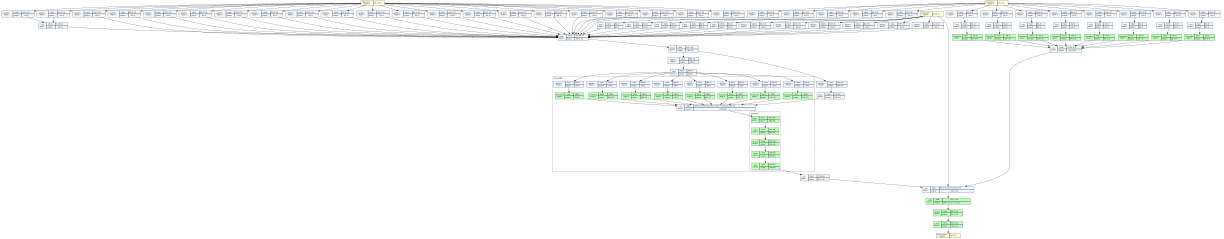

In [14]:
!pip install torchview
from torchview import draw_graph

BATCH_SIZE = 64
seq_len = 6

efm_graph = draw_graph(
    model=early_fusion_model,
    input_size=(
        (BATCH_SIZE, seq_len, 6),   # dense_feat
        (BATCH_SIZE, seq_len, 8),   # sparse_feat
        (BATCH_SIZE, seq_len, 19)   # dense_additional
    ),
    dtypes=[
        torch.float,  # dense_feat
        torch.long,   # sparse_feat
        torch.float   # dense_additional
    ],
    expand_nested=True,
    hide_inner_tensors=True,
    hide_module_functions=True
)

efm_graph.visual_graph.attr(size="17,18")

display(efm_graph.visual_graph)

In [15]:
# Loss Function

def masked_weighted_huber_loss(predictions, targets, valid_lens, delta=HUBER_LOSS_THRESH, pos_weight=4.5, delay_threshold_scaled=None):
    seq_len = predictions.shape[1]
    mask = torch.arange(seq_len, device=predictions.device).unsqueeze(0) < valid_lens.unsqueeze(1)
    mask = mask.unsqueeze(-1).expand_as(predictions)

    loss_fn = nn.HuberLoss(delta=delta, reduction="none")
    elementwise_loss = loss_fn(predictions, targets)

    weights = torch.ones_like(targets)
    weights[targets > delay_threshold_scaled.to(targets.device)] = pos_weight

    weighted_loss = elementwise_loss * weights
    return weighted_loss[mask].mean()

# Optimizer

optimizer = optim.AdamW(early_fusion_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGTH_DECAY)


In [16]:
# Metrics

def find_optimal_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    optimal_idx = np.argmax(f1_scores[:-1])
    return thresholds[optimal_idx]

def compute_all_metrics(pred_delays, true_delays, true_labels, valid_lens, dep_threshold=None, arr_threshold=None):
    """
    Compute regression (MSE, MAE) and classification (Accuracy, Precision, Recall, F1, AUC)
    for arrival and departure delays, masking out padded time steps.

    Args:
        pred_delays: Tensor [batch, seq_len, 2] - predicted delays (arr, dep)
        true_delays: Tensor [batch, seq_len, 2] - ground truth delays (arr, dep)
        true_labels: Tensor [batch, seq_len, 2] - binary labels (1 if delay > 15 min)
        valid_lens:  Tensor [batch] - number of valid (non-padded) steps per sequence

    Returns:
        dict: nested dict with metrics for arrival ('arr') and departure ('dep'),
              each containing regression and classification metrics.
    """
    if ((arr_threshold is None) or (dep_threshold is None)):
        raise ValueError("Threshold cannot be None")

    batch_size, seq_len = pred_delays.shape[0], pred_delays.shape[1]
    device = pred_delays.device

    # Mask: True for valid positions, False for padding
    mask = torch.arange(seq_len, device=device).expand(
        batch_size, seq_len
    ) < valid_lens.unsqueeze(1)  # [batch, seq_len]

    # Flatten only valid entries for each target column
    pred_arr = pred_delays[:, :, 0][mask].flatten().cpu().numpy()
    pred_dep = pred_delays[:, :, 1][mask].flatten().cpu().numpy()
    true_arr = true_delays[:, :, 0][mask].flatten().cpu().numpy()
    true_dep = true_delays[:, :, 1][mask].flatten().cpu().numpy()
    label_arr = true_labels[:, :, 0][mask].flatten().cpu().numpy()
    label_dep = true_labels[:, :, 1][mask].flatten().cpu().numpy()

    # Helper for classification metrics
    def clf_metrics(y_true, y_pred, y_score):
        """
        Compute accuracy, precision, recall, F1 from binary predictions,
        and AUC from raw scores.
        """
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_true, y_score)
            # y_score are raw scores (obtained through regression-task model) for AUC
        except ValueError:
            auc = 0.5  # fallback if only one class present
        return acc, prec, rec, f1, auc

    # Regression metrics
    mse_arr = mean_squared_error(true_arr, pred_arr)
    mae_arr = mean_absolute_error(true_arr, pred_arr)
    mse_dep = mean_squared_error(true_dep, pred_dep)
    mae_dep = mean_absolute_error(true_dep, pred_dep)

    # Classification: "delay" threshold at variable time
    pred_bin_arr = (pred_arr > arr_threshold).astype(int)
    pred_bin_dep = (pred_dep > dep_threshold).astype(int)

    acc_arr, prec_arr, rec_arr, f1_arr, auc_arr = clf_metrics(
        label_arr, pred_bin_arr, pred_arr
    )
    acc_dep, prec_dep, rec_dep, f1_dep, auc_dep = clf_metrics(
        label_dep, pred_bin_dep, pred_dep
    )

    metrics = {
        "arr_reg": {"MSE": mse_arr, "MAE": mae_arr},
        "dep_reg": {"MSE": mse_dep, "MAE": mae_dep},
        "arr_clf": {
            "Accuracy": acc_arr,
            "Precision": prec_arr,
            "Recall": rec_arr,
            "F1": f1_arr,
            "AUC": auc_arr,
        },
        "dep_clf": {
            "Accuracy": acc_dep,
            "Precision": prec_dep,
            "Recall": rec_dep,
            "F1": f1_dep,
            "AUC": auc_dep,
        },
    }
    return metrics

## 5. Training and Evaluation

Since the `MLP` embedding extraction is performed directly within the `forward` pass of the fusion model, the effective training and evaluation procedure is focused on the `LSTM` component, which receives the additional static information provided by the `MLP` embeddings.

Therefore, the training procedure follows the same methodology used for the original `LSTM` model, with the difference that the sequential model now benefits from the integration of static tabular features.


In [17]:
best_val_loss = float("inf")
patience_counter = 0
early_stop = False

best_model_state = None

train_loss_history = []
val_loss_history = []

for epoch in range(NUM_EPOCHS):
    print(f"Doing epoch {epoch}...")
    early_fusion_model.train()
    running_train_loss = 0.0

    for batch in train_loader:
        dense_feat, sparse_feat, labels, valid_lens, targets, dense_additional = [
            tensor.to(DEVICE) for tensor in batch
        ]

        optimizer.zero_grad()

        predictions = early_fusion_model(
            scale_tensors(dense_feat, mean=dense_mean, std=dense_std),
            sparse_feat,
            scale_tensors(dense_additional, mean=dense_additional_mean, std=dense_additional_std)
        )

        loss = masked_weighted_huber_loss(
            predictions,
            scale_tensors(targets.float(), mean=delay_mean, std=delay_std),
            valid_lens,
            delay_threshold_scaled=delay_threshold_scaled
        )

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * dense_feat.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    early_fusion_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            dense_feat, sparse_feat, labels, valid_lens, targets, dense_additional = [
                tensor.to(DEVICE) for tensor in batch
            ]

            predictions = early_fusion_model(
                scale_tensors(dense_feat, mean=dense_mean, std=dense_std),
                sparse_feat,
                scale_tensors(dense_additional, mean=dense_additional_mean, std=dense_additional_std)
            )

            loss = masked_weighted_huber_loss(
                predictions,
                scale_tensors(targets.float(), mean=delay_mean, std=delay_std),
                valid_lens,
                delay_threshold_scaled=delay_threshold_scaled
            )

            running_val_loss += loss.item() * dense_feat.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(early_fusion_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            early_stop = True
            break

if best_model_state is not None:
    early_fusion_model.load_state_dict(best_model_state)

print("Training and evaluation process completed successfully.")

Doing epoch 0...
Epoch [1/50] | Train Loss: 0.6766 | Val Loss: 0.7121
Doing epoch 1...
Epoch [2/50] | Train Loss: 0.6723 | Val Loss: 0.7165
Doing epoch 2...
Epoch [3/50] | Train Loss: 0.6698 | Val Loss: 0.7105
Doing epoch 3...
Epoch [4/50] | Train Loss: 0.6684 | Val Loss: 0.7095
Doing epoch 4...
Epoch [5/50] | Train Loss: 0.6672 | Val Loss: 0.7095
Doing epoch 5...
Epoch [6/50] | Train Loss: 0.6665 | Val Loss: 0.7073
Doing epoch 6...
Epoch [7/50] | Train Loss: 0.6662 | Val Loss: 0.7071
Doing epoch 7...
Epoch [8/50] | Train Loss: 0.6655 | Val Loss: 0.7078
Doing epoch 8...
Epoch [9/50] | Train Loss: 0.6650 | Val Loss: 0.7074
Doing epoch 9...
Epoch [10/50] | Train Loss: 0.6647 | Val Loss: 0.7065
Doing epoch 10...
Epoch [11/50] | Train Loss: 0.6646 | Val Loss: 0.7065
Doing epoch 11...
Epoch [12/50] | Train Loss: 0.6642 | Val Loss: 0.7064
Doing epoch 12...
Epoch [13/50] | Train Loss: 0.6640 | Val Loss: 0.7060
Doing epoch 13...
Epoch [14/50] | Train Loss: 0.6640 | Val Loss: 0.7062
Doing epoch

KeyboardInterrupt: 

In [35]:
# Training was manually stopped due to excessive runtime and limited computational resources.
# No early-stopping patience threshold was applied; however, the latest improvements were negligible (O(10^-3)),
# suggesting that the model had reached a performance plateau.

# We saved the model in .pt file, and reload it here. Restart session was needed, but we saved training curves.

# Doing epoch 0...
# Epoch [1/50] | Train Loss: 0.6766 | Val Loss: 0.7121
# Doing epoch 1...
# Epoch [2/50] | Train Loss: 0.6723 | Val Loss: 0.7165
# Doing epoch 2...
# Epoch [3/50] | Train Loss: 0.6698 | Val Loss: 0.7105
# Doing epoch 3...
# Epoch [4/50] | Train Loss: 0.6684 | Val Loss: 0.7095
# Doing epoch 4...
# Epoch [5/50] | Train Loss: 0.6672 | Val Loss: 0.7095
# Doing epoch 5...
# Epoch [6/50] | Train Loss: 0.6665 | Val Loss: 0.7073
# Doing epoch 6...
# Epoch [7/50] | Train Loss: 0.6662 | Val Loss: 0.7071
# Doing epoch 7...
# Epoch [8/50] | Train Loss: 0.6655 | Val Loss: 0.7078
# Doing epoch 8...
# Epoch [9/50] | Train Loss: 0.6650 | Val Loss: 0.7074
# Doing epoch 9...
# Epoch [10/50] | Train Loss: 0.6647 | Val Loss: 0.7065
# Doing epoch 10...
# Epoch [11/50] | Train Loss: 0.6646 | Val Loss: 0.7065
# Doing epoch 11...
# Epoch [12/50] | Train Loss: 0.6642 | Val Loss: 0.7064
# Doing epoch 12...
# Epoch [13/50] | Train Loss: 0.6640 | Val Loss: 0.7060
# Doing epoch 13...
# Epoch [14/50] | Train Loss: 0.6640 | Val Loss: 0.7062

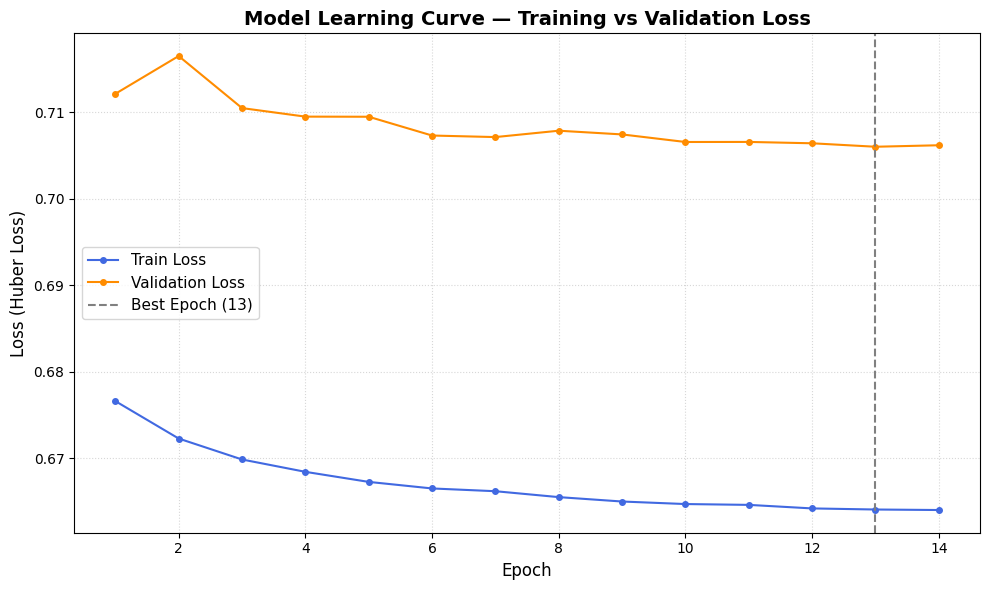

In [20]:
# Learning curves

epochs_range = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss_history, marker="o", markersize=4, label="Train Loss", color="royalblue")
plt.plot(epochs_range, val_loss_history, marker="o", markersize=4, label="Validation Loss", color="darkorange")
best_epoch = epochs_range[val_loss_history.index(min(val_loss_history))]
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (Huber Loss)", fontsize=12)
plt.title("Model Learning Curve — Training vs Validation Loss", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.5, linestyle=":")
plt.tight_layout()
plt.show()

In [ ]:
early_fusion_model.eval()
all_preds, all_targets, all_labels, all_lens = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        dense_feat, sparse_feat, labels, valid_lens, targets, dense_additional = [
            t.to(DEVICE) for t in batch
        ]

        preds = early_fusion_model(
            scale_tensors(dense_feat, mean=dense_mean, std=dense_std),
            sparse_feat,
            dense_additional
        )

        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())
        all_labels.append(labels.cpu())
        all_lens.append(valid_lens.cpu())

test_preds = torch.cat(all_preds, dim=0)
test_preds = unscale_tensors(test_preds)
test_targets = torch.cat(all_targets, dim=0)
test_labels = torch.cat(all_labels, dim=0)
test_lens = torch.cat(all_lens, dim=0)

test_metrics = compute_all_metrics(test_preds, test_targets, test_labels, test_lens, arr_threshold=15, dep_threshold=15)

print("\n=== Test Set Metrics ===")
for target in ["arr", "dep"]:
    print(f"\n{target.upper()} Regression:")
    for k, v in test_metrics[f"{target}_reg"].items():
        print(f"  {k}: {v:.4f}")
    print(f"{target.upper()} Classification:")
    for k, v in test_metrics[f"{target}_clf"].items():
        print(f"  {k}: {v:.4f}")

In [ ]:
# save metrics history and best model and dump them to a pickle file

epochs_run = (
    epoch + 1
)  # actual number of epochs completed (accounts for early stopping)

results = {
    "train_loss_history": train_loss_history,
    "val_loss_history": val_loss_history,
    "best_val_loss": best_val_loss,
    "test_metrics": test_metrics,
    "delay_mean": delay_mean,
    "delay_std": delay_std,
    "dense_mean": dense_mean,
    "dense_std": dense_std,
    "dense_additional_mean": dense_additional_mean,
    "dense_additional_std": dense_additional_std,
    "epochs_run": epochs_run,
    "hyperparams": {
        "hidden_units": HIDDEN_UNITS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "num_epochs": NUM_EPOCHS,
        "fraction": fraction,
    },
}

with open("training_results.pkl", "wb") as f:
    pickle.dump(results, f)

# Save best model separately
torch.save(best_model_state, "best_model.pt")

## 6. Results

In [ ]:
# Baseline check: what if we always predicted the mean delay for every sample?
mask_test = torch.arange(test_preds.shape[1]).unsqueeze(0) < test_lens.unsqueeze(1)  # [N, seq_len]

true_arr_valid = test_targets[:, :, 0][mask_test]
true_dep_valid = test_targets[:, :, 1][mask_test]

baseline_pred_arr = delay_mean[0].item()  # constant: train mean ARR delay
baseline_pred_dep = delay_mean[1].item()  # constant: train mean DEP delay

baseline_mae_arr = (true_arr_valid - baseline_pred_arr).abs().mean().item()
baseline_mae_dep = (true_dep_valid - baseline_pred_dep).abs().mean().item()

print(f"Baseline (predict train mean) MAE -- ARR: {baseline_mae_arr:.4f}, DEP: {baseline_mae_dep:.4f}")
print(f"Model MAE -- ARR: {test_metrics['arr_reg']['MAE']:.4f}, DEP: {test_metrics['dep_reg']['MAE']:.4f}")


In [ ]:
# Naive baseline classifier: predicts "delayed" (1) for every sample
# using only the class prior (fraction of delayed samples in train set),
# via a fixed probability threshold at 0.5 -- equivalent to always predicting
# the majority class.

train_labels = train_dataset.tensors[2]  # [N, seq_len, 2]
train_valid_lens = train_dataset.tensors[3]  # [N]

seq_len = train_labels.shape[1]
mask_train = torch.arange(seq_len).unsqueeze(0) < train_valid_lens.unsqueeze(1)

label_arr_train = train_labels[:, :, 0][mask_train].float()
label_dep_train = train_labels[:, :, 1][mask_train].float()

# class prior = mean of binary labels (fraction delayed)
prior_arr = label_arr_train.mean().item()
prior_dep = label_dep_train.mean().item()

print(f"Prior P(delayed) -- ARR: {prior_arr:.4f}, DEP: {prior_dep:.4f}")

# naive prediction: always predict the majority class
naive_pred_arr = 1 if prior_arr > 0.5 else 0
naive_pred_dep = 1 if prior_dep > 0.5 else 0

mask_test = torch.arange(test_preds.shape[1]).unsqueeze(0) < test_lens.unsqueeze(1)
true_label_arr_test = test_labels[:, :, 0][mask_test].numpy()
true_label_dep_test = test_labels[:, :, 1][mask_test].numpy()

naive_preds_arr = np.full_like(true_label_arr_test, naive_pred_arr)
naive_preds_dep = np.full_like(true_label_dep_test, naive_pred_dep)

naive_acc_arr = accuracy_score(true_label_arr_test, naive_preds_arr)
naive_acc_dep = accuracy_score(true_label_dep_test, naive_preds_dep)

print(f"Naive baseline Accuracy -- ARR: {naive_acc_arr:.4f}, DEP: {naive_acc_dep:.4f}")

In [ ]:
# Trivial baseline: always predict "delayed" (positive) for everyone
always_pos_preds_arr = np.ones_like(true_label_arr_test)
always_pos_preds_dep = np.ones_like(true_label_dep_test)

always_pos_acc_arr = accuracy_score(true_label_arr_test, always_pos_preds_arr)
always_pos_prec_arr = precision_score(true_label_arr_test, always_pos_preds_arr, zero_division=0)
always_pos_rec_arr = recall_score(true_label_arr_test, always_pos_preds_arr, zero_division=0)
always_pos_f1_arr = f1_score(true_label_arr_test, always_pos_preds_arr, zero_division=0)

always_pos_acc_dep = accuracy_score(true_label_dep_test, always_pos_preds_dep)
always_pos_prec_dep = precision_score(true_label_dep_test, always_pos_preds_dep, zero_division=0)
always_pos_rec_dep = recall_score(true_label_dep_test, always_pos_preds_dep, zero_division=0)
always_pos_f1_dep = f1_score(true_label_dep_test, always_pos_preds_dep, zero_division=0)

print("=== Trivial 'always predict delayed' baseline ===")
print(f"ARR -- Accuracy: {always_pos_acc_arr:.4f}, Precision: {always_pos_prec_arr:.4f}, Recall: {always_pos_rec_arr:.4f}, F1: {always_pos_f1_arr:.4f}")
print(f"DEP -- Accuracy: {always_pos_acc_dep:.4f}, Precision: {always_pos_prec_dep:.4f}, Recall: {always_pos_rec_dep:.4f}, F1: {always_pos_f1_dep:.4f}")

In [ ]:
early_fusion_model.eval()
val_all_preds, val_all_targets, val_all_labels, val_all_lens = [], [], [], []

with torch.no_grad():
    for batch in val_loader:
        dense_feat, sparse_feat, labels, valid_lens, targets, dense_additional = [
            t.to(DEVICE) for t in batch
        ]
        preds = early_fusion_model(
            scale_tensors(dense_feat, mean=dense_mean, std=dense_std),
            sparse_feat,
            scale_tensors(dense_additional, mean=dense_additional_mean, std=dense_additional_std)
        )
        val_all_preds.append(preds.cpu())
        val_all_targets.append(targets.cpu())
        val_all_labels.append(labels.cpu())
        val_all_lens.append(valid_lens.cpu())

val_preds = torch.cat(val_all_preds, dim=0)
val_preds = unscale_tensors(val_preds, mean=delay_mean, std=delay_std)
val_labels = torch.cat(val_all_labels, dim=0)
val_lens = torch.cat(val_all_lens, dim=0)

# extract valid (non-padded) entries to compute thresholds
val_mask = torch.arange(val_preds.shape[1]).unsqueeze(0) < val_lens.unsqueeze(1)
val_pred_arr = val_preds[:, :, 0][val_mask].numpy()
val_pred_dep = val_preds[:, :, 1][val_mask].numpy()
val_label_arr = val_labels[:, :, 0][val_mask].numpy()
val_label_dep = val_labels[:, :, 1][val_mask].numpy()

opt_arr_threshold = find_optimal_threshold(val_label_arr, val_pred_arr) # optimal (F1 score - wise) thresh computed on validation set
opt_dep_threshold = find_optimal_threshold(val_label_dep, val_pred_dep)

print(f"Optimal thresholds (from validation set) -- ARR: {opt_arr_threshold:.4f}, DEP: {opt_dep_threshold:.4f}")

In [ ]:
test_metrics_var_thresh = compute_all_metrics(test_preds, test_targets, test_labels, test_lens, arr_threshold=opt_arr_threshold, dep_threshold=opt_dep_threshold)

print("\n=== Test Set Metrics (variable threshoold)===")
for target in ["arr", "dep"]:
    print(f"\n{target.upper()} Regression:")
    for k, v in test_metrics_var_thresh[f"{target}_reg"].items():
        print(f"  {k}: {v:.4f}")
    print(f"{target.upper()} Classification:")
    for k, v in test_metrics_var_thresh[f"{target}_clf"].items():
        print(f"  {k}: {v:.4f}")

In [ ]:
results_var_thresh = {
    "train_loss_history": train_loss_history,
    "val_loss_history": val_loss_history,
    "best_val_loss": best_val_loss,
    "test_metrics": test_metrics_var_thresh,
    "delay_mean": delay_mean,
    "delay_std": delay_std,
    "dense_mean": dense_mean,
    "dense_std": dense_std,
    "dense_additional_mean": dense_additional_mean,
    "dense_additional_std": dense_additional_std,
    "epochs_run": epochs_run,
    "hyperparams": {
        "hidden_units": HIDDEN_UNITS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "num_epochs": NUM_EPOCHS,
        "fraction": fraction,
    },
}

with open("training_results_var_thresh.pkl", "wb") as f:
    pickle.dump(results_var_thresh, f)